Libraries loaded.
TensorFlow  : 2.20.0
Keras       : 3.13.2

Target forecast date : 2024-12-12
Input window date    : 2024-12-11
Expected actual file : actual_2024-12-11.csv
Cleared previous session files:
  removed: actual_2024-12-11.csv
  removed: actual_2024-12-10.csv
  removed: saved_model.zip
  removed: saved_model (6).zip
  removed: saved_model/

Ready for fresh uploads.
UPLOAD 1 OF 2 — Select saved_model.zip


Saving saved_model (6).zip to saved_model (6).zip
Found    : saved_model (6).zip  ✓
Renamed  : saved_model (6).zip  →  saved_model.zip
Extracted: saved_model.zip  →  saved_model/
  lstm_model.pkl  (1,333,742 bytes)  ✓
  scaler.pkl  (1,322 bytes)  ✓
  meta.pkl  (211 bytes)  ✓

saved_model.zip loaded successfully.
UPLOAD 2 OF 2 — Select actual_2024-12-11.csv


Saving actual_2024-12-11.csv to actual_2024-12-11.csv
Found    : actual_2024-12-11.csv  ✓

Both files ready:
  saved_model.zip      ✓
  actual_2024-12-11.csv  ✓
Loading model from pickle...
  Method: manual architecture rebuild  (version independent)

Model loaded — no retraining.
  Keras version  : 3.13.2
  LOOK_BACK      : 96
  FORECAST_STEPS : 96
  n_features     : 21
  load_cols      : ['LOAD1', 'LOAD2', 'LOAD3', 'LOAD4', 'LOAD5', 'LOAD6', 'LOAD7', 'LOAD8', 'LOAD9', 'LOAD10', 'LOAD11', 'LOAD12', 'LOAD13', 'LOAD14', 'LOAD15', 'LOAD16', 'LOAD17', 'LOAD18', 'LOAD19', 'LOAD20', 'LOAD21']
Raw file : actual_2024-12-11.csv
  Raw shape     : (2016, 21)
  Raw date span : 2024-12-11 00:00:00  →  NaT
  Total NaNs    : 40320

  After dropping fully-blank rows : 2016 → 96 rows
  After dropping NaT timestamps  : 96 → 96 rows
  After dropping any-NaN rows    : 96 → 96 rows

Clean date span : 2024-12-11 00:00:00  →  2024-12-11 23:45:00
Clean rows      : 96  (need at least 96)

Input window (last 9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV download started.


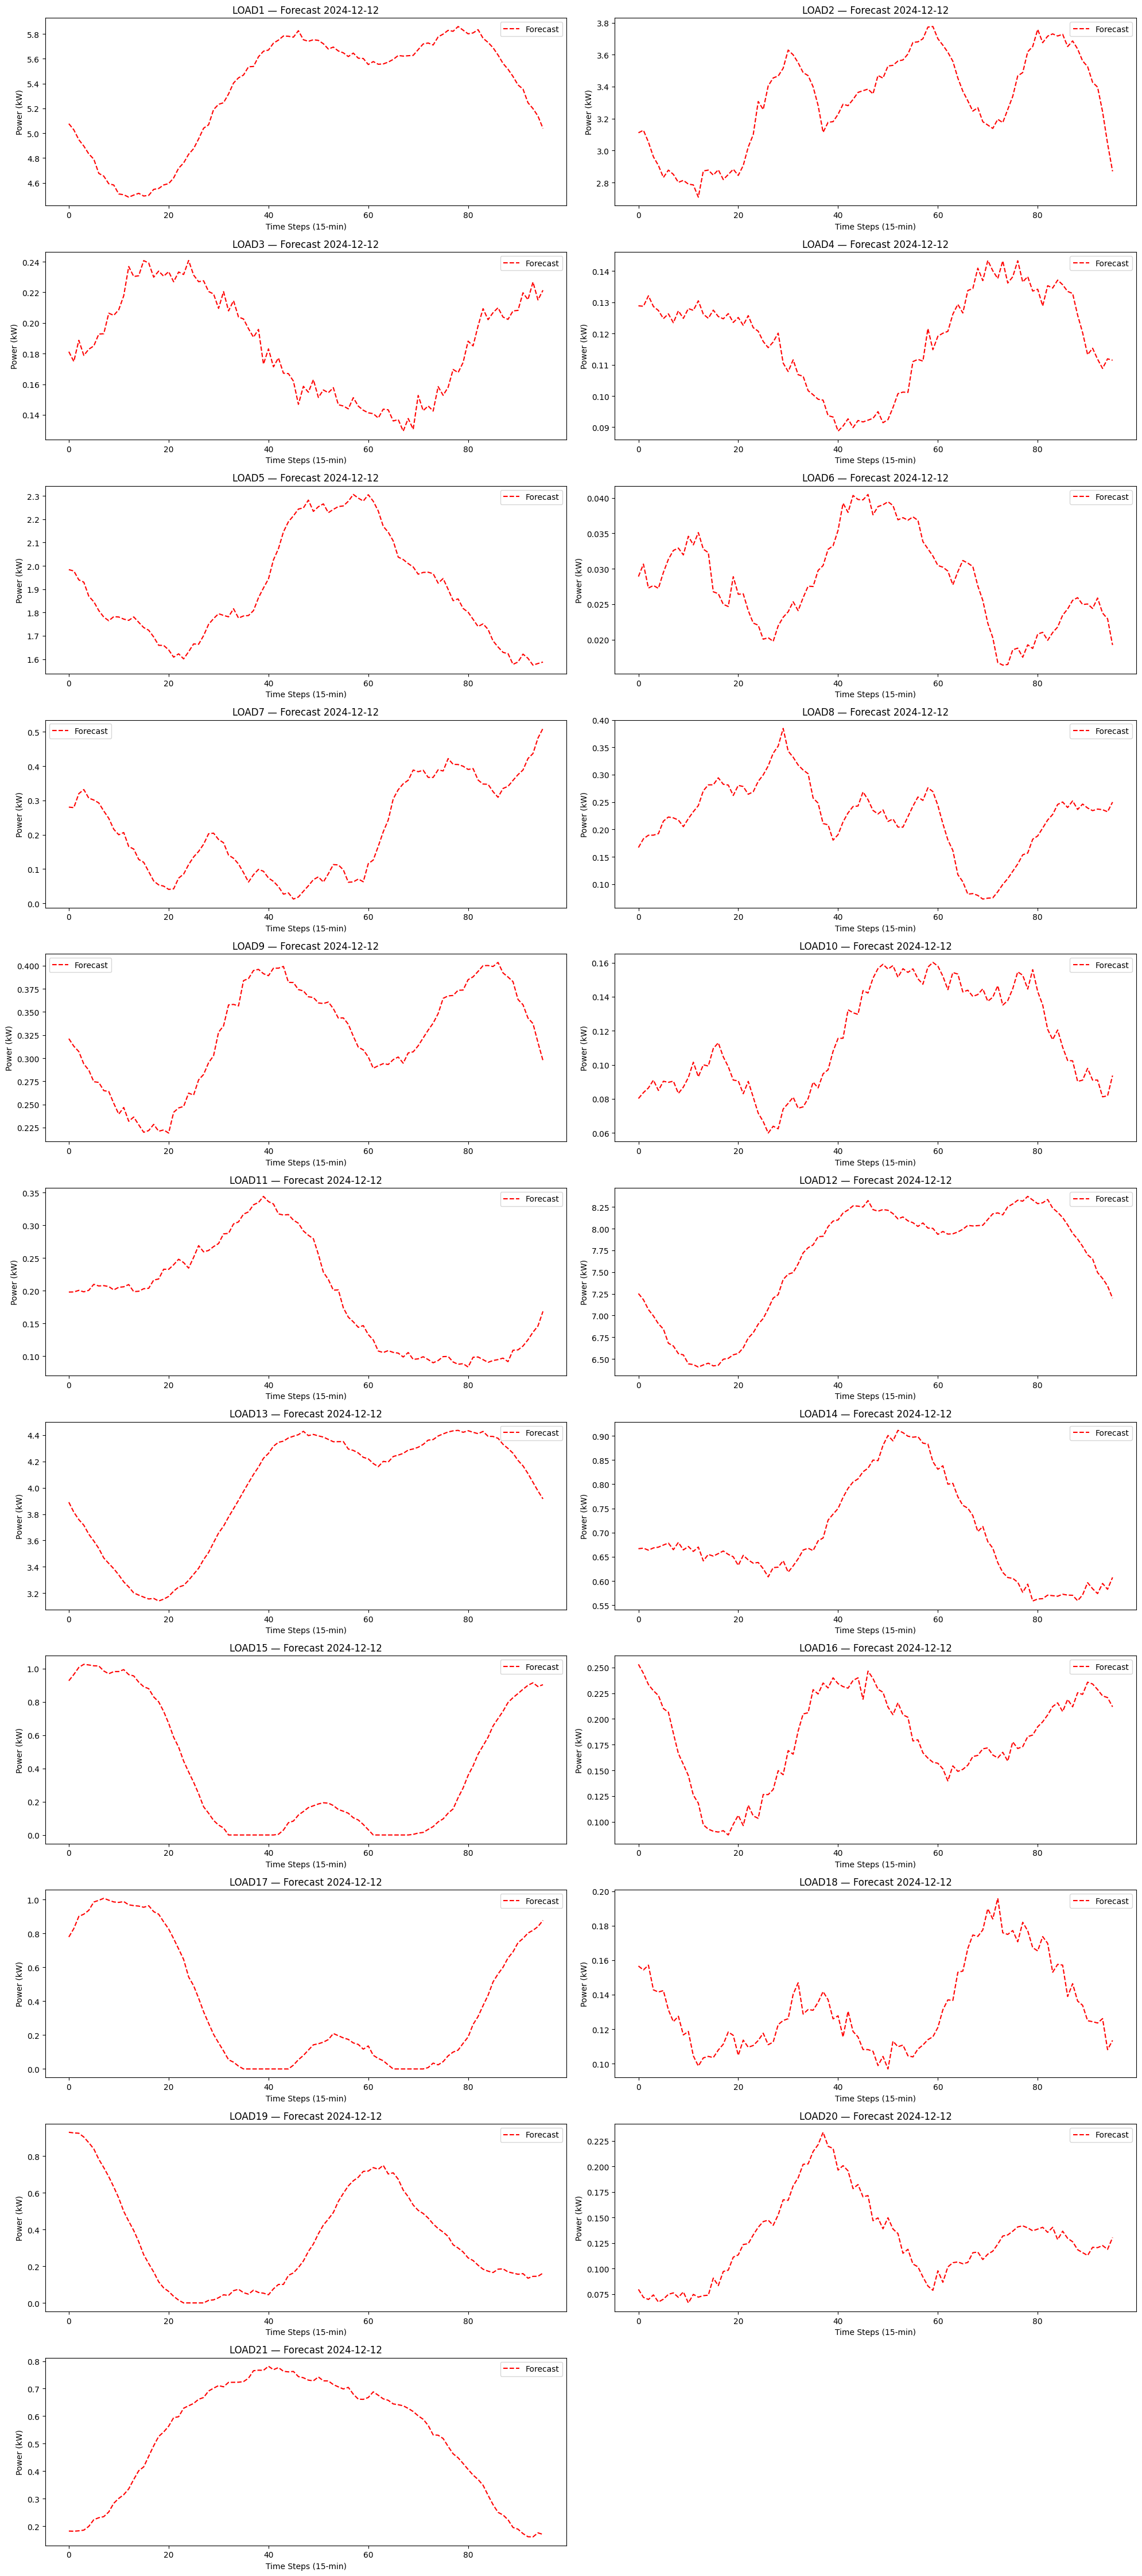

Combined plot  →  Forecast_2024-12-12/All_Loads_2024-12-12.png

Saving 21 individual plots...
All individual plots saved.
Plots ZIP  →  Forecast_2024-12-12/Load_Forecasts_All.zip


In [18]:
# =============================================================================
#  NOTEBOOK 2 — DAILY FORECAST  (run every day, no retraining)
#
#  WHAT YOU NEED TO UPLOAD EACH DAY:
#    1. saved_model.zip         ← downloaded from Notebook 1 (keep forever)
#    2. actual_YYYY-MM-DD.csv   ← previous day's actual load data
#                                  (can contain more than 96 rows — auto-cleaned)
#
#  WHAT THIS PRODUCES:
#    Forecast_YYYY-MM-DD/
#      Next_Day_Load_Forecast_21.csv   ← 96-row forecast
#      All_Loads_YYYY-MM-DD.png        ← combined 21-load subplot
#      Load_Forecast_Plots/
#        LOAD1_forecast.png            ← one PNG per load (dpi=300)
#        ...  (21 PNGs total)
#      Load_Forecasts_All.zip
#    Forecast_YYYY-MM-DD.zip           ← single download of everything
#
#  ACTUAL CSV FORMAT:
#    Timestamp,LOAD1,LOAD2,...,LOAD21
#    2024-12-11 00:00:00,5.75,3.46,...
#    ...
#    File can have more than 96 rows — the code always uses the last 96
#    clean rows as the input window. Blank/NaN rows are removed automatically.
#
#  DAILY USAGE:
#    Forecast 2024-12-11 → set TARGET_DATE='2024-12-11', upload actual_2024-12-10.csv
#    Forecast 2024-12-12 → set TARGET_DATE='2024-12-12', upload actual_2024-12-11.csv
#    Forecast 2024-12-13 → set TARGET_DATE='2024-12-13', upload actual_2024-12-12.csv
#    ... and so on.
#
#  IMPORTANT: Start a fresh Colab runtime for each new forecast day
#    Runtime → Disconnect and delete runtime → Reconnect
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Configuration
#   *** CHANGE TARGET_DATE EVERY DAY ***
# ─────────────────────────────────────────────────────────────────────────────

TARGET_DATE = '2024-12-12'
# ↑ Set this to the date you want to FORECAST.
#   Upload the actual CSV for the day BEFORE this date.
#   Example: TARGET_DATE = '2024-12-12'  →  upload actual_2024-12-11.csv


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import files as colab_files
import os, pickle, shutil, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# Compute window date here so it is available throughout the notebook
window_str = (pd.Timestamp(TARGET_DATE) - timedelta(days=1)).strftime('%Y-%m-%d')

print('Libraries loaded.')
print(f'TensorFlow  : {tf.__version__}')
print(f'Keras       : {tf.keras.__version__}')
print(f'\nTarget forecast date : {TARGET_DATE}')
print(f'Input window date    : {window_str}')
print(f'Expected actual file : actual_{window_str}.csv')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Clear any leftover files from previous runs
#   Removes old actual_*.csv and saved_model files so Colab does not
#   auto-rename your new uploads (the (1).csv / (1).zip problem).
# ─────────────────────────────────────────────────────────────────────────────

# Remove old actual CSV files
removed = []
for f in glob.glob('actual_*.csv'):
    os.remove(f)
    removed.append(f)

# Remove old saved_model zip and folder
for f in glob.glob('saved_model*.zip'):
    os.remove(f)
    removed.append(f)
if os.path.exists('saved_model'):
    shutil.rmtree('saved_model')
    removed.append('saved_model/')

if removed:
    print('Cleared previous session files:')
    for f in removed:
        print(f'  removed: {f}')
else:
    print('No previous files to clear.')

print('\nReady for fresh uploads.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Upload saved_model.zip  (Upload 1 of 2)
#   File picker opens — select ONLY:  saved_model.zip
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print('UPLOAD 1 OF 2 — Select saved_model.zip')
print('=' * 55)

up1 = colab_files.upload()

# Find the uploaded zip (handles Colab renaming e.g. "saved_model (1).zip")
MODEL_ZIP = None
for fn in up1.keys():
    if 'saved_model' in fn and fn.endswith('.zip'):
        MODEL_ZIP = fn
        break

if MODEL_ZIP is None:
    raise FileNotFoundError(
        'saved_model.zip not found in uploaded files.\n'
        'Re-run this cell and select saved_model.zip.')

print(f'Found    : {MODEL_ZIP}  ✓')

# Standardise filename
if MODEL_ZIP != 'saved_model.zip':
    shutil.copy(MODEL_ZIP, 'saved_model.zip')
    print(f'Renamed  : {MODEL_ZIP}  →  saved_model.zip')

# Extract
MODEL_DIR = 'saved_model'
shutil.unpack_archive('saved_model.zip', MODEL_DIR)
print(f'Extracted: saved_model.zip  →  {MODEL_DIR}/')

# Verify all 3 pkl files
for fn in ['lstm_model.pkl', 'scaler.pkl', 'meta.pkl']:
    fpath = os.path.join(MODEL_DIR, fn)
    if not os.path.exists(fpath):
        raise FileNotFoundError(
            f'{fn} missing inside saved_model.zip.\n'
            'Download saved_model.zip from Notebook 1 and try again.')
    print(f'  {fn}  ({os.path.getsize(fpath):,} bytes)  ✓')

print('\nsaved_model.zip loaded successfully.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Upload actual CSV  (Upload 2 of 2)
#   File picker opens — select ONLY:  actual_YYYY-MM-DD.csv
#   (the day BEFORE your TARGET_DATE)
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print(f'UPLOAD 2 OF 2 — Select actual_{window_str}.csv')
print('=' * 55)

up2 = colab_files.upload()

# Find the uploaded CSV (handles Colab renaming e.g. "actual_2024-12-11 (1).csv")
ACTUAL_CSV = None
for fn in up2.keys():
    if window_str in fn and fn.endswith('.csv'):
        ACTUAL_CSV = fn
        break

if ACTUAL_CSV is None:
    raise FileNotFoundError(
        f'actual_{window_str}.csv not found in uploaded files.\n'
        f'Re-run this cell and select actual_{window_str}.csv')

print(f'Found    : {ACTUAL_CSV}  ✓')

# Standardise filename
ACTUAL_STANDARD = f'actual_{window_str}.csv'
if ACTUAL_CSV != ACTUAL_STANDARD:
    shutil.copy(ACTUAL_CSV, ACTUAL_STANDARD)
    print(f'Renamed  : {ACTUAL_CSV}  →  {ACTUAL_STANDARD}')

print(f'\nBoth files ready:')
print(f'  saved_model.zip      ✓')
print(f'  {ACTUAL_STANDARD}  ✓')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Load model + scaler from pickle  (zero retraining)
#   Compatible with Keras 2.x and Keras 3.x
# ─────────────────────────────────────────────────────────────────────────────

# Load pickle files
with open(f'{MODEL_DIR}/lstm_model.pkl', 'rb') as f:
    payload = pickle.load(f)
with open(f'{MODEL_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open(f'{MODEL_DIR}/meta.pkl', 'rb') as f:
    meta = pickle.load(f)

# Read hyperparameters
LOOK_BACK      = payload['look_back']        # 96
FORECAST_STEPS = payload['forecast_steps']   # 96
n_feat         = payload['n_features']       # 21
load_cols      = meta['load_cols']           # ['LOAD1',...,'LOAD21']

# ── Rebuild model — 3 fallback methods for Keras 2.x / 3.x compatibility ────
def _rebuild_model(payload):
    weights = payload['weights']
    config  = payload['model_config']

    # Method 1 — Keras 2.x
    try:
        m = tf.keras.models.model_from_config(config)
        m.set_weights(weights)
        print('  Method: tf.keras.models.model_from_config  (Keras 2.x)')
        return m
    except Exception:
        pass

    # Method 2 — Keras 3.x
    try:
        import keras
        m = keras.saving.model_from_config(config)
        m.set_weights(weights)
        print('  Method: keras.saving.model_from_config  (Keras 3.x)')
        return m
    except Exception:
        pass

    # Method 3 — Manual rebuild (always works regardless of Keras version)
    lb = payload['look_back']
    fs = payload['forecast_steps']
    nf = payload['n_features']
    m  = Sequential([
        LSTM(100, return_sequences=True, input_shape=(lb, nf)),
        Dropout(0.2),
        LSTM(100, return_sequences=False),
        Dropout(0.2),
        Dense(fs * nf),
    ])
    m.set_weights(weights)
    print('  Method: manual architecture rebuild  (version independent)')
    return m

print('Loading model from pickle...')
model = _rebuild_model(payload)
model.compile(optimizer='adam', loss='mse')

print('\nModel loaded — no retraining.')
print(f'  Keras version  : {tf.keras.__version__}')
print(f'  LOOK_BACK      : {LOOK_BACK}')
print(f'  FORECAST_STEPS : {FORECAST_STEPS}')
print(f'  n_features     : {n_feat}')
print(f'  load_cols      : {load_cols}')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Load and clean the actual CSV
#
#  KEY FIXES applied here:
#   1. Drops fully-blank rows (NaN rows that inflate row count to 2016 etc.)
#   2. Drops rows with NaT (invalid) timestamps
#   3. Drops any remaining rows with NaN values
#   4. Takes the last 96 clean rows as the input window
#      → works correctly even if the file contains multiple days of data
# ─────────────────────────────────────────────────────────────────────────────

actual_df = pd.read_csv(ACTUAL_STANDARD, index_col='Timestamp', parse_dates=True)
actual_df = actual_df.sort_index()

print(f'Raw file : {ACTUAL_STANDARD}')
print(f'  Raw shape     : {actual_df.shape}')
print(f'  Raw date span : {actual_df.index[0]}  →  {actual_df.index[-1]}')
print(f'  Total NaNs    : {actual_df.isnull().sum().sum()}')

# Step 1 — Drop rows where ALL columns are NaN (blank rows at bottom of file)
before = len(actual_df)
actual_df = actual_df.dropna(how='all')
print(f'\n  After dropping fully-blank rows : {before} → {len(actual_df)} rows')

# Step 2 — Drop rows with NaT (invalid) index
before = len(actual_df)
actual_df = actual_df[actual_df.index.notna()]
print(f'  After dropping NaT timestamps  : {before} → {len(actual_df)} rows')

# Step 3 — Drop rows that still have any NaN value
before = len(actual_df)
actual_df = actual_df.dropna(how='any')
print(f'  After dropping any-NaN rows    : {before} → {len(actual_df)} rows')

print(f'\nClean date span : {actual_df.index[0]}  →  {actual_df.index[-1]}')
print(f'Clean rows      : {len(actual_df)}  (need at least {LOOK_BACK})')

# Validate enough clean rows
if len(actual_df) < LOOK_BACK:
    raise ValueError(
        f'Only {len(actual_df)} clean rows after removing NaN/blank rows; '
        f'need {LOOK_BACK}.\n'
        f'Check your CSV file — it may have too much missing data.')

# Validate columns match training columns
missing_cols = [c for c in load_cols if c not in actual_df.columns]
if missing_cols:
    raise ValueError(
        f'These columns are missing from the CSV: {missing_cols}\n'
        f'CSV columns found   : {actual_df.columns.tolist()}\n'
        f'Columns expected    : {load_cols}')

# Show the exact 96-row window that will be used
window_96_df = actual_df[load_cols].iloc[-LOOK_BACK:]
print(f'\nInput window (last {LOOK_BACK} clean rows):')
print(f'  From : {window_96_df.index[0]}')
print(f'  To   : {window_96_df.index[-1]}')
print(f'  Min  : {window_96_df.values.min():.4f}')
print(f'  Max  : {window_96_df.values.max():.4f}')
print(f'  NaN  : {window_96_df.isnull().sum().sum()}')
print('\nValidation passed ✓')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Generate forecast
# ─────────────────────────────────────────────────────────────────────────────

target_date = pd.Timestamp(TARGET_DATE)

print(f'Generating forecast for  {TARGET_DATE}  ...')
print(f'Input window : {window_96_df.index[0]}  →  {window_96_df.index[-1]}')

# Extract raw values
window_96 = window_96_df.values                          # (96, 21)

# Scale using the training scaler
window_sc = scaler.transform(window_96)                  # (96, 21)

print(f'\nScaled window stats:')
print(f'  Min : {window_sc.min():.4f}  (expected ≥ 0)')
print(f'  Max : {window_sc.max():.4f}  (expected ≤ 1 for in-range data)')
print(f'  NaN : {np.isnan(window_sc).sum()}  (must be 0)')

if np.isnan(window_sc).any():
    raise ValueError(
        'NaN values found after scaling — input data has invalid values.\n'
        'Check your actual CSV for missing or corrupt entries.')

# Reshape and predict
inp       = window_sc.reshape(1, LOOK_BACK, n_feat)      # (1, 96, 21)
pred_flat = model.predict(inp, verbose=0)                 # (1, 96*21)
pred_sc   = pred_flat.reshape(FORECAST_STEPS, n_feat)     # (96, 21)

print(f'\nRaw prediction stats (scaled):')
print(f'  Min : {pred_sc.min():.4f}')
print(f'  Max : {pred_sc.max():.4f}')
print(f'  NaN : {np.isnan(pred_sc).sum()}  (must be 0)')

# Inverse transform back to kW
pred_kw = scaler.inverse_transform(pred_sc)              # (96, 21)

print(f'\nPrediction stats (kW, before clip):')
print(f'  Min : {pred_kw.min():.4f}')
print(f'  Max : {pred_kw.max():.4f}')
print(f'  Negatives : {(pred_kw < 0).sum()}')

# Clip negatives to zero (physically impossible load)
pred_kw = np.clip(pred_kw, 0, None)

print(f'\nFinal prediction stats (kW, after clip):')
print(f'  Min : {pred_kw.min():.4f}')
print(f'  Max : {pred_kw.max():.4f}')

# Build forecast DataFrame
forecast_times = pd.date_range(
    start=target_date, periods=FORECAST_STEPS, freq='15min')
forecast_df = pd.DataFrame(pred_kw, index=forecast_times, columns=load_cols)
forecast_df.index.name = 'Timestamp'

print(f'\nForecast complete.')
print(f'  Period : {forecast_df.index[0]}  →  {forecast_df.index[-1]}')
print(f'  Shape  : {forecast_df.shape}')
print('\nForecast preview (first 4 rows):')
print(forecast_df.head(4).to_string())


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Save CSV + plots
# ─────────────────────────────────────────────────────────────────────────────

out_dir   = f'Forecast_{TARGET_DATE}'
plots_dir = os.path.join(out_dir, 'Load_Forecast_Plots')
os.makedirs(plots_dir, exist_ok=True)

# 1. Forecast CSV
csv_path = os.path.join(out_dir, 'load_Forecast.csv')
forecast_df.to_csv(csv_path)
print(f'Forecast CSV  →  {csv_path}')

# Download CSV immediately (no need to wait for plots)
colab_files.download(csv_path)
print('CSV download started.')

# 2. Combined 21-load subplot
plt.figure(figsize=(20, 45))
for i, col in enumerate(load_cols):
    plt.subplot(11, 2, i + 1)
    plt.plot(forecast_df[col].values, label='Forecast',
             color='red', linestyle='--')
    plt.title(f'{col} — Forecast {TARGET_DATE}')
    plt.xlabel('Time Steps (15-min)')
    plt.ylabel('Power (kW)')
    plt.legend()
plt.tight_layout()
combined_path = os.path.join(out_dir, f'All_Loads_{TARGET_DATE}.png')
plt.savefig(combined_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Combined plot  →  {combined_path}')

# 3. Individual PNGs (dpi=300)
print(f'\nSaving {len(load_cols)} individual plots...')
for col in load_cols:
    plt.figure(figsize=(10, 5))
    plt.plot(forecast_df[col].values, label='Forecast',
             color='red', linestyle='--')
    plt.title(f'Forecast: {col}  ({TARGET_DATE})')
    plt.xlabel('Time Steps (15-min)')
    plt.ylabel('Power (kW)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig(
        os.path.join(plots_dir, f"{col.replace(' ', '_')}_forecast.png"),
        dpi=300, bbox_inches='tight')
    plt.close()
print('All individual plots saved.')

# 4. ZIP individual plots
zip_plots_base = os.path.join(out_dir, 'Load_Forecasts_All')
shutil.make_archive(zip_plots_base, 'zip', plots_dir)
print(f'Plots ZIP  →  {zip_plots_base}.zip')





--- Evaluation: Forecast vs Actual (2024-12-12) ---
Load           | MSE        | RMSE       | R²        
----------------------------------------------------
LOAD1          | 0.0395     | 0.1987     | 0.8482    
LOAD2          | 0.1511     | 0.3888     | -0.4571   
LOAD3          | 0.0186     | 0.1365     | 0.0968    
LOAD4          | 0.0007     | 0.0270     | -0.3949   
LOAD5          | 0.0838     | 0.2895     | -0.0606   
LOAD6          | 0.0002     | 0.0144     | -0.5790   
LOAD7          | 0.0143     | 0.1196     | 0.4447    
LOAD8          | 0.0274     | 0.1656     | -0.3309   
LOAD9          | 0.0066     | 0.0814     | 0.3438    
LOAD10         | 0.0364     | 0.1907     | 0.0667    
LOAD11         | 0.0292     | 0.1710     | 0.2399    
LOAD12         | 0.0806     | 0.2838     | 0.8482    
LOAD13         | 0.0727     | 0.2697     | 0.7826    
LOAD14         | 0.0801     | 0.2830     | 0.1822    
LOAD15         | 0.2417     | 0.4916     | 0.4932    
LOAD16         | 0.0584     | 

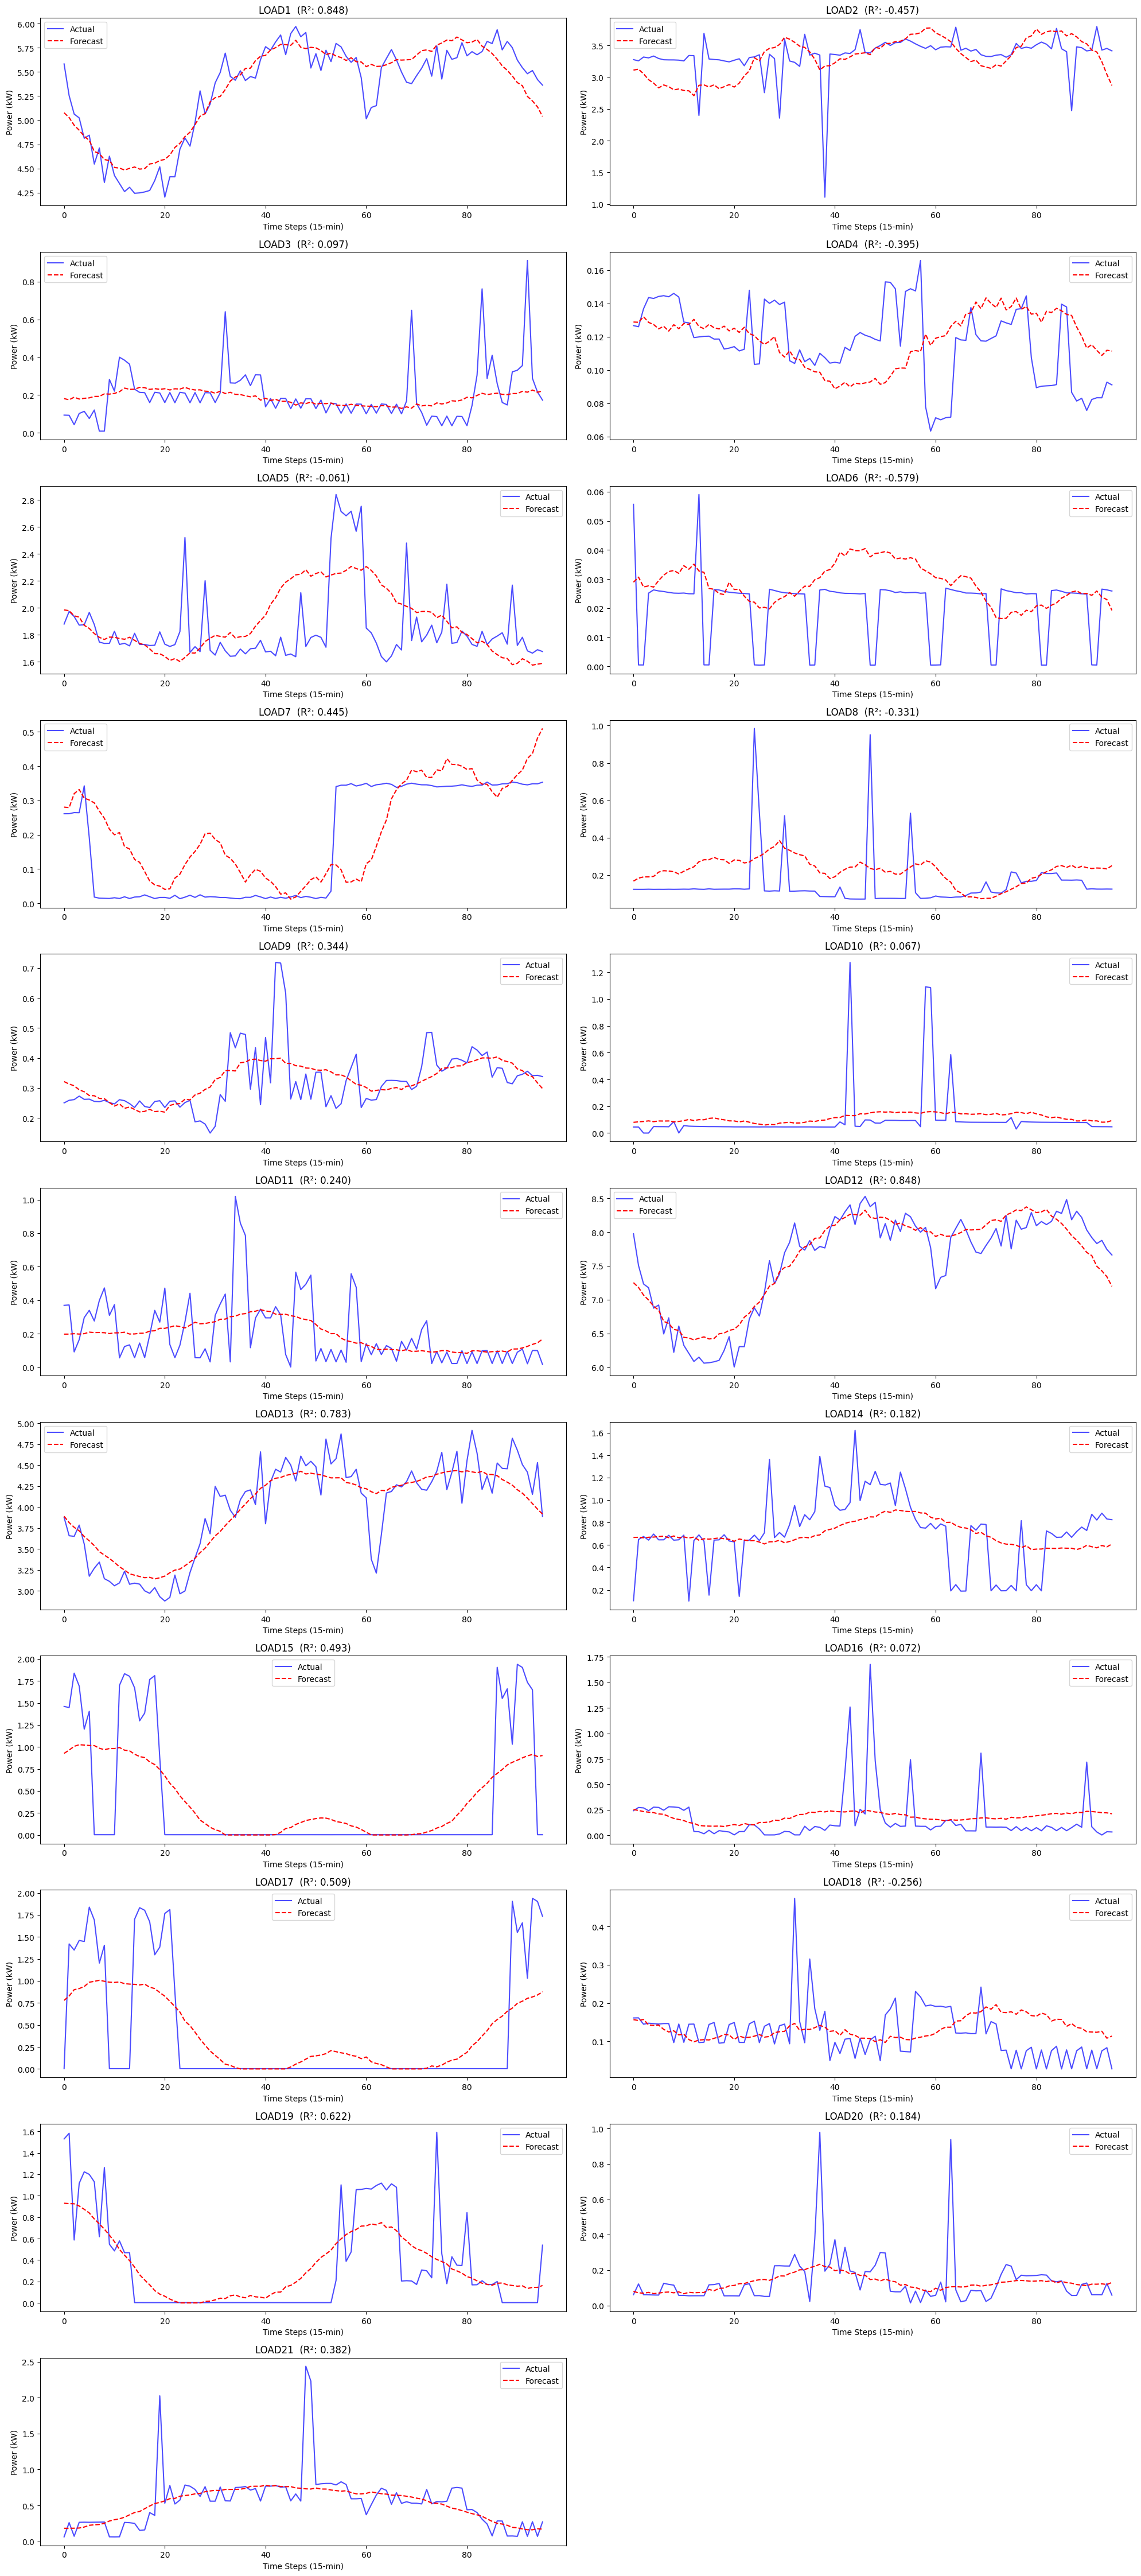

Overlay plots  →  Forecast_2024-12-12/Overlay_Plots/
Master ZIP  →  Forecast_2024-12-12.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.

OUTPUT FILE TREE  —  Forecast_2024-12-12/
Forecast_2024-12-12/
  All_Loads_2024-12-12.png  (1,058,641 bytes)
  Load_Forecasts_All.zip  (2,759,781 bytes)
  load_Forecast.csv  (23,126 bytes)
  load_Forecast_21.csv  (23,126 bytes)
  load_Forecast_{TARGET_DATE}.csv  (23,126 bytes)
  Load_Forecast_Plots/
    LOAD10_forecast.png  (165,826 bytes)
    LOAD11_forecast.png  (141,447 bytes)
    LOAD12_forecast.png  (149,383 bytes)
    LOAD13_forecast.png  (139,374 bytes)
    LOAD14_forecast.png  (157,999 bytes)
    LOAD15_forecast.png  (135,659 bytes)
    LOAD16_forecast.png  (169,930 bytes)
    LOAD17_forecast.png  (137,471 bytes)
    LOAD18_forecast.png  (167,330 bytes)
    LOAD19_forecast.png  (139,001 bytes)
    LOAD1_forecast.png  (139,344 bytes)
    LOAD20_forecast.png  (161,093 bytes)
    LOAD21_forecast.png  (138,002 bytes)
    LOAD2_forecast.png  (160,471 bytes)
    LOAD3_forecast.png  (167,261 bytes)
    LOAD4_forecast.png  (160,855 bytes)
    LOAD5_forecast.png  (147

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Optional: evaluate forecast vs actual
#
#  If you have the actual data for TARGET_DATE, upload actual_TARGET_DATE.csv
#  to the Colab working directory and run this cell.
#  Skip if actual data is not yet available.
# ─────────────────────────────────────────────────────────────────────────────

target_actual_fname = f'actual_{TARGET_DATE}.csv'

if os.path.exists(target_actual_fname):
    target_actual = pd.read_csv(target_actual_fname,
                                index_col='Timestamp', parse_dates=True)
    # Clean the actual file the same way
    target_actual = target_actual.dropna(how='all')
    target_actual = target_actual[target_actual.index.notna()]
    target_actual = target_actual.dropna(how='any')

    common = target_actual.index.intersection(forecast_df.index)

    # Metrics table
    print(f'\n--- Evaluation: Forecast vs Actual ({TARGET_DATE}) ---')
    print(f"{'Load':<14} | {'MSE':<10} | {'RMSE':<10} | {'R²':<10}")
    print('-' * 52)
    for col in load_cols:
        a   = target_actual.loc[common, col].values
        p   = forecast_df.loc[common, col].values
        mse = mean_squared_error(a, p)
        print(f"{col:<14} | {mse:<10.4f} | {np.sqrt(mse):<10.4f}"
              f" | {r2_score(a, p):<10.4f}")

    # Overlay plots
    overlay_dir = os.path.join(out_dir, 'Overlay_Plots')
    os.makedirs(overlay_dir, exist_ok=True)

    # Combined overlay subplot
    plt.figure(figsize=(20, 45))
    for i, col in enumerate(load_cols):
        a  = target_actual.loc[common, col].values
        p  = forecast_df.loc[common, col].values
        r2 = r2_score(a, p)
        plt.subplot(11, 2, i + 1)
        plt.plot(a, label='Actual',   color='blue', alpha=0.7)
        plt.plot(p, label='Forecast', color='red',  linestyle='--')
        plt.title(f'{col}  (R²: {r2:.3f})')
        plt.xlabel('Time Steps (15-min)')
        plt.ylabel('Power (kW)')
        plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(overlay_dir,
                f'Actual_vs_Forecast_{TARGET_DATE}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Individual overlay PNGs
    for col in load_cols:
        a  = target_actual.loc[common, col].values
        p  = forecast_df.loc[common, col].values
        r2 = r2_score(a, p)
        plt.figure(figsize=(10, 5))
        plt.plot(a, label='Actual',   color='blue', alpha=0.7)
        plt.plot(p, label='Forecast', color='red',  linestyle='--')
        plt.title(f'Actual vs Forecast{TARGET_DATE}: {col}  (R²: {r2:.3f})')
        plt.xlabel('Time Steps (15-min)')
        plt.ylabel('Power (kW)')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.savefig(
            os.path.join(overlay_dir,
                         f"{col.replace(' ', '_')}_overlay.png"),
            dpi=300, bbox_inches='tight')
        plt.close()
    print(f'Overlay plots  →  {overlay_dir}/')

else:
    print(f'{target_actual_fname} not found — evaluation skipped.')
    print('Upload it and re-run this cell when actual data is available.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Download everything as one ZIP
# ─────────────────────────────────────────────────────────────────────────────

zip_name = f'Forecast_{TARGET_DATE}'
shutil.make_archive(zip_name, 'zip', out_dir)
print(f'Master ZIP  →  {zip_name}.zip')
colab_files.download(f'{zip_name}.zip')
print('Download started.')

# File tree
print(f'\nOUTPUT FILE TREE  —  {out_dir}/')
print('=' * 55)
for root, dirs, fnames in os.walk(out_dir):
    depth  = root.replace(out_dir, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for fn in sorted(fnames):
        size = os.path.getsize(os.path.join(root, fn))
        print(f"{'  '*(depth+1)}{fn}  ({size:,} bytes)")